# Notebook de procesamiento de datos.

## Importacion de librerias

In [2]:
import numpy as np
import pandas as pd
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import ast
from datetime import datetime, timezone
import re


In [3]:
BASE_PATH = '../datasets/new_datasets/twitter15/'
TREE_DIR = os.path.join(BASE_PATH, 'tree')
LABEL_PATH = os.path.join(BASE_PATH, 'label.txt')
SOURCE_PATH = os.path.join(BASE_PATH, 'source_tweets.txt')

## Importación de datos

Leer arboles.

In [4]:

rows = []

c = 0
k = 0
q = 0

posts_in_event = set()

for root, dirs, files in os.walk(TREE_DIR):
    print('root:', root)
    for fname in files:

        c += 1
        q -= 1

        source_tree_id = os.path.splitext(fname)[0]

        fpath = os.path.join(root, fname)

        with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
            
            #Primera linea es ROOT->(user_id, tweet_id, delay)
            for line in f:

                k += 1
                q += 1

                line = line.strip()
                if not line or '->' not in line:
                    continue

                left_str, right_str = line.split('->', 1)
                parent = ast.literal_eval(left_str)
                child  = ast.literal_eval(right_str)

                p_uid, p_tid, p_delay = parent
                c_uid, c_tid, c_delay = child

                is_new_post = (p_tid != c_tid)

                posts_in_event.add((str(c_uid), str(c_tid)))

                rows.append({
                    'source_tree_id': source_tree_id,
                    'is_new_post': is_new_post,
                    'parent_user_id': str(p_uid),
                    'parent_tweet_id': str(p_tid),
                    'parent_delay_min': float(p_delay),
                    'child_user_id': str(c_uid),
                    'child_tweet_id': str(c_tid),
                    'child_delay_min': float(c_delay),
                })


df15 = pd.DataFrame(rows, columns=[
    'source_tree_id', 'is_new_post',
    'parent_user_id', 'parent_tweet_id', 'parent_delay_min',
    'child_user_id',  'child_tweet_id',  'child_delay_min'
])

print('C:', c)
print('K:', k)
print('Q:', q)

print('Total number of rows/edges:', len(df15))

for col in ['source_tree_id', 'parent_user_id', 'parent_tweet_id', 'child_user_id', 'child_tweet_id']:
    df15[col] = df15[col].astype('string')


root: ../datasets/new_datasets/twitter15/tree
C: 1490
K: 607289
Q: 605799
Total number of rows/edges: 607289


Leer labels

In [5]:
label_counts = Counter()
label_of = {}

label_map = {
    'non-rumor': 'NR',
    'false': 'FR',
    'true': 'TR',
    'unverified': 'UR',
}


label_counts = Counter()
if os.path.exists(LABEL_PATH):
    with open(LABEL_PATH, 'r', encoding='utf-8', errors='ignore') as f:
        for raw in f:
            s = raw.strip()
            if not s:
                continue
            # expecting "label:tweetid"
            try:
                label_str, sid = s.split(':', 1)
            except ValueError:
                # tolerate malformed lines
                continue
            label_str = label_str.strip().lower()
            sid = sid.strip()

            short = label_map.get(label_str)
            if not short:
                # unknown label -> skip
                continue

            label_of[sid] = short
            label_counts[short] += 1


    print("\nCounts by class:")
    print(f"# of non-rumors (NR):     {label_counts.get('NR', 0)}")
    print(f"# of false-rumors (FR):   {label_counts.get('FR', 0)}")
    print(f"# of true-rumors (TR):    {label_counts.get('TR', 0)}")
    print(f"# of unverified (UR):     {label_counts.get('UR', 0)}")
else:
    print("\n(label.txt not found — skipping label counts)")


Counts by class:
# of non-rumors (NR):     374
# of false-rumors (FR):   370
# of true-rumors (TR):    372
# of unverified (UR):     374


Combinar labels con tweets.

In [6]:
df15['parent_label'] = df15['parent_tweet_id'].map(label_of)
df15.head()

,source_tree_id,is_new_post,parent_user_id,parent_tweet_id,parent_delay_min,child_user_id,child_tweet_id,child_delay_min,parent_label
0,265953285247209472,True,ROOT,ROOT,0.0,39364684,265953285247209472,0.00,NaN
1,265953285247209472,True,39364684,265953285247209472,0.0,21061006,265953402234748928,0.45,FR
2,265953285247209472,True,39364684,265953285247209472,0.0,18513522,265953502839308289,0.85,FR
3,265953285247209472,True,39364684,265953285247209472,0.0,38251731,265953577145614336,1.15,FR
4,265953285247209472,True,39364684,265953285247209472,0.0,22369434,265953587149021185,1.20,FR


Agregar tiempo de padres e hijos.

In [7]:
def snowflake_to_datetime(snowflake_id: str) -> datetime:
    """
    Convert a Twitter snowflake ID to a UTC datetime object.
    Twitter snowflakes are 64-bit integers where the first 42 bits represent
    the timestamp in milliseconds since Twitter's epoch (2010-11-04 01:42:54 UTC).
    """
    twitter_epoch = 1288834974657  # in milliseconds
    snowflake_int = int(snowflake_id)
    timestamp_ms = (snowflake_int >> 22) + twitter_epoch
    timestamp_s = timestamp_ms / 1000.0
    return datetime.fromtimestamp(timestamp_s, tz=timezone.utc)

In [8]:
snowflake_to_datetime('273182568298450945')

datetime.datetime(2012, 11, 26, 21, 52, 54, 426000, tzinfo=datetime.timezone.utc)

In [9]:
df15['source_datetime'] = df15['source_tree_id'].apply(lambda x: snowflake_to_datetime(int(x)))
df15['child_datetime'] = df15['child_tweet_id'].apply(lambda x: snowflake_to_datetime(int(x)))

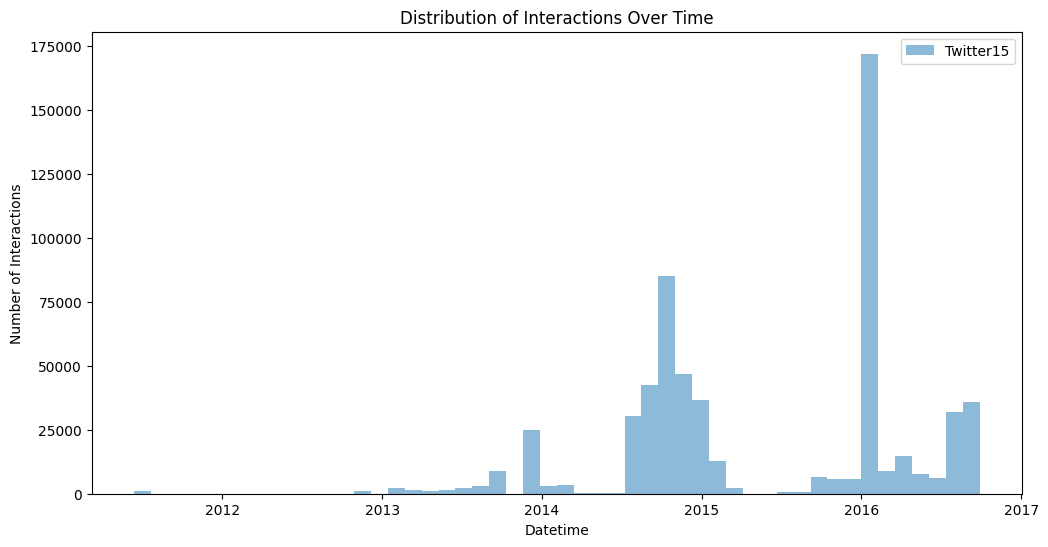

In [9]:
fig = plt.figure(figsize=(12, 6))
plt.hist(df15['source_datetime'], bins=50, alpha=0.5, label='Twitter15')
plt.xlabel('Datetime')
plt.ylabel('Number of Interactions')
plt.title('Distribution of Interactions Over Time')
plt.legend()
plt.show()

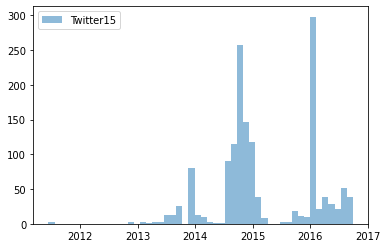

In [26]:
first_time = (df15
              .sort_values('source_datetime')
              .groupby('source_tree_id')['source_datetime']
              .first())
first_time = pd.to_datetime(first_time)

plt.hist(first_time, bins=50, alpha=0.5, label='Twitter15')
plt.legend()


Si una persona a su propio tweet cuenta como engagment? Lol si de hecho kjsd

Limpiar tweets

In [10]:
text_of = {}
with open(SOURCE_PATH, 'r', encoding='ascii', errors='ignore') as source_tweets:
    source = source_tweets.readlines()
    for i in range(len(source)):
        tid, text = source[i].strip('\n').split('\t', 1)

        text_of[tid] = text
df15['text'] = df15['parent_tweet_id'].map(text_of)
    

In [11]:
df15['text'] = df15['text'].str.replace(r'([.,!?()])', r'\1', regex=True)
df15['text'] = df15['text'].str.replace(r'\s{2,}', ' ', regex=True)
df15['text'] = df15['text'].str.lower()

Division tiempos

In [ ]:
# Se puede cambiar pero de momento tomo desde octubre 2014 hasta fin de 2016
time_limit = datetime(2016, 12, 31, tzinfo=timezone.utc)
time_start = datetime(2014, 10, 1, tzinfo=timezone.utc)
mask = (df15['source_datetime'] >= time_start) & (df15['source_datetime'] <= time_limit)
df15 = df15.loc[mask].reset_index(drop=True)

Ventanas de actividad

In [ ]:
# Este codigo demora mucho. Esto fue lo que entendi por ventanas del usuario si no lo es ignorar, pero
# si es necesario, usarlo con precaucion.
users = set(df15['parent_user_id']).union(set(df15['child_user_id']))
user_time_frame = dict.fromkeys(users, (0, 0))
for uid in users:
    user_posts = df15[(df15['parent_user_id'] == uid) | (df15['child_user_id'] == uid)]
    if not user_posts.empty:
        first_post_time = min(user_posts['parent_delay_min'].min(), user_posts['child_delay_min'].min())
        last_post_time = max(user_posts['parent_delay_min'].max(), user_posts['child_delay_min'].max())
        user_time_frame[uid] = (first_post_time, last_post_time)
print(user_time_frame)

split train test

In [ ]:
train_df, test_df = train_test_split(df15, test_size=0.2)